[2026-07-11 14:26:07] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-11 14:26:27] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-11 14:26:27] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-11 14:26:30] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-11 14:26:33] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-11 14:26:33] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-11 14:26:33] [info     ] ========== 数据检查 ==========
[2026-07-11 14:26:33] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-01-15~2024-02-08,0.0046
2024-09-24~2024-10-08,0.0103

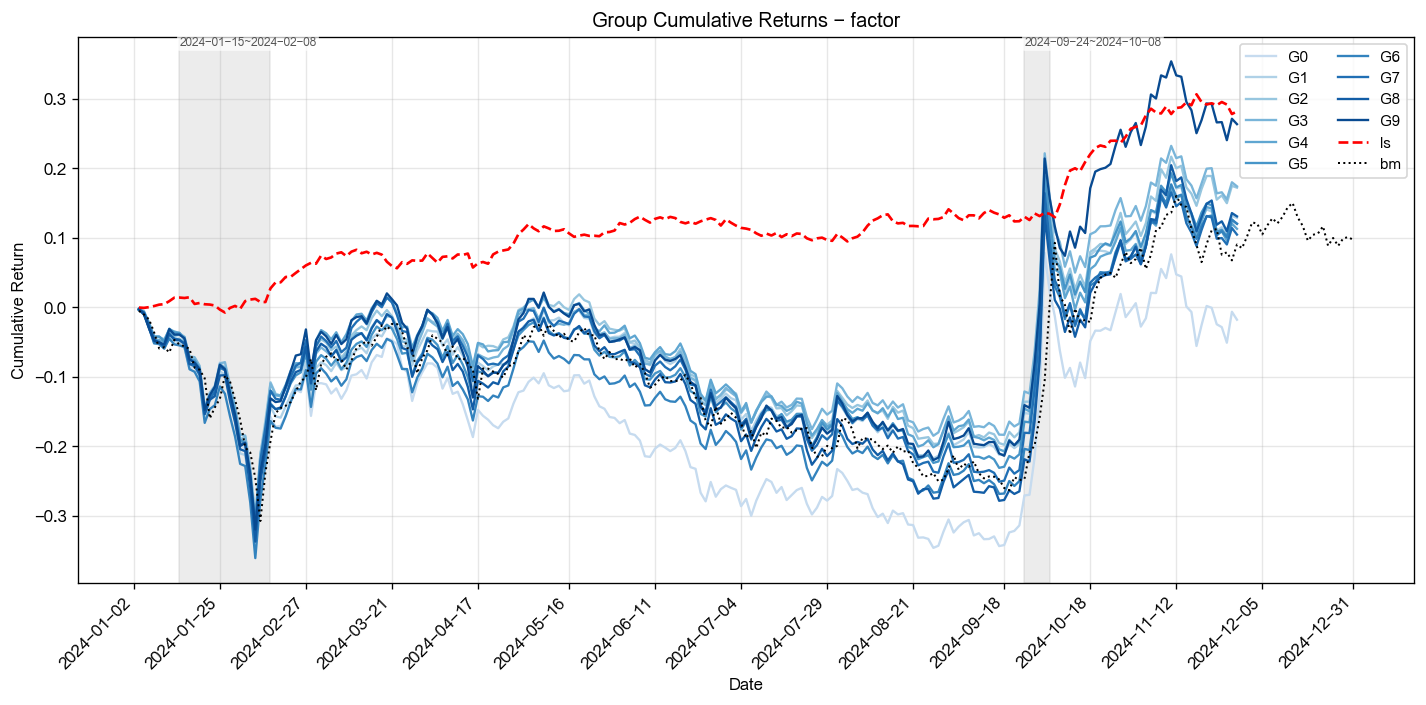
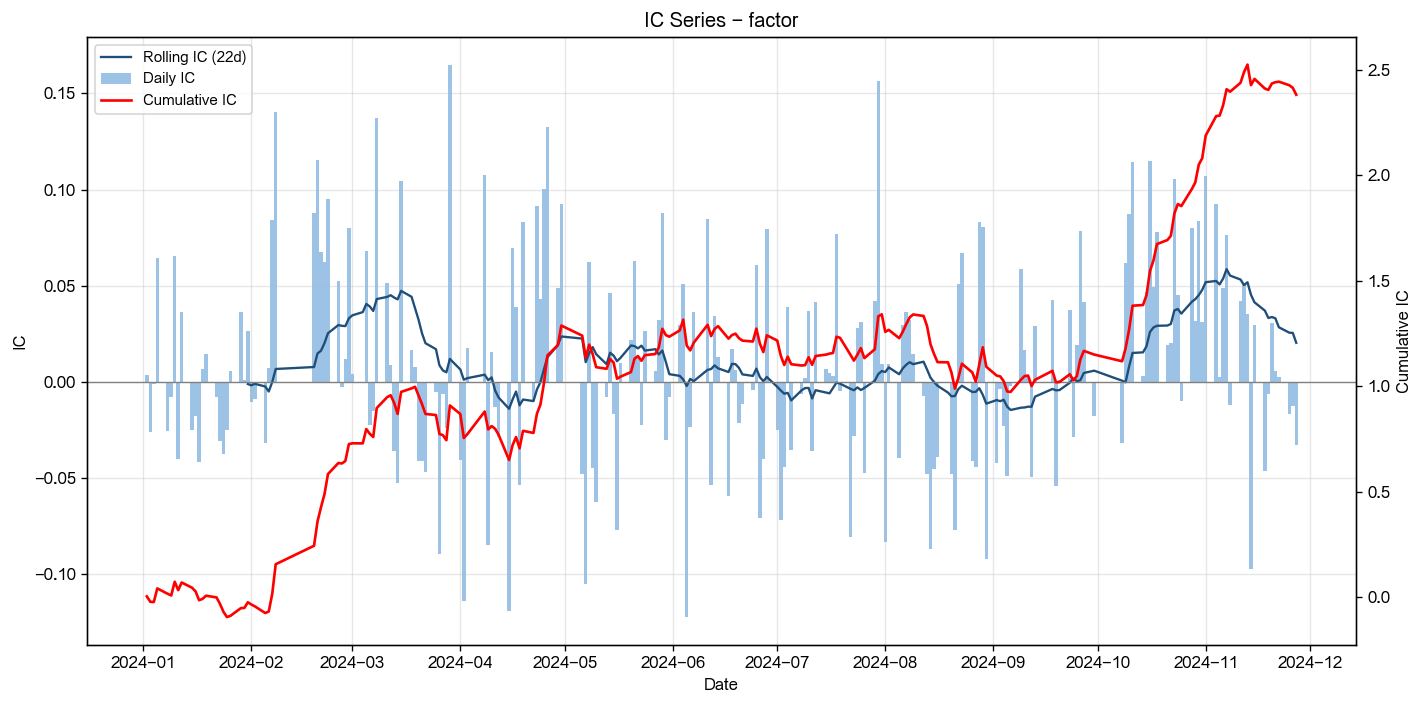
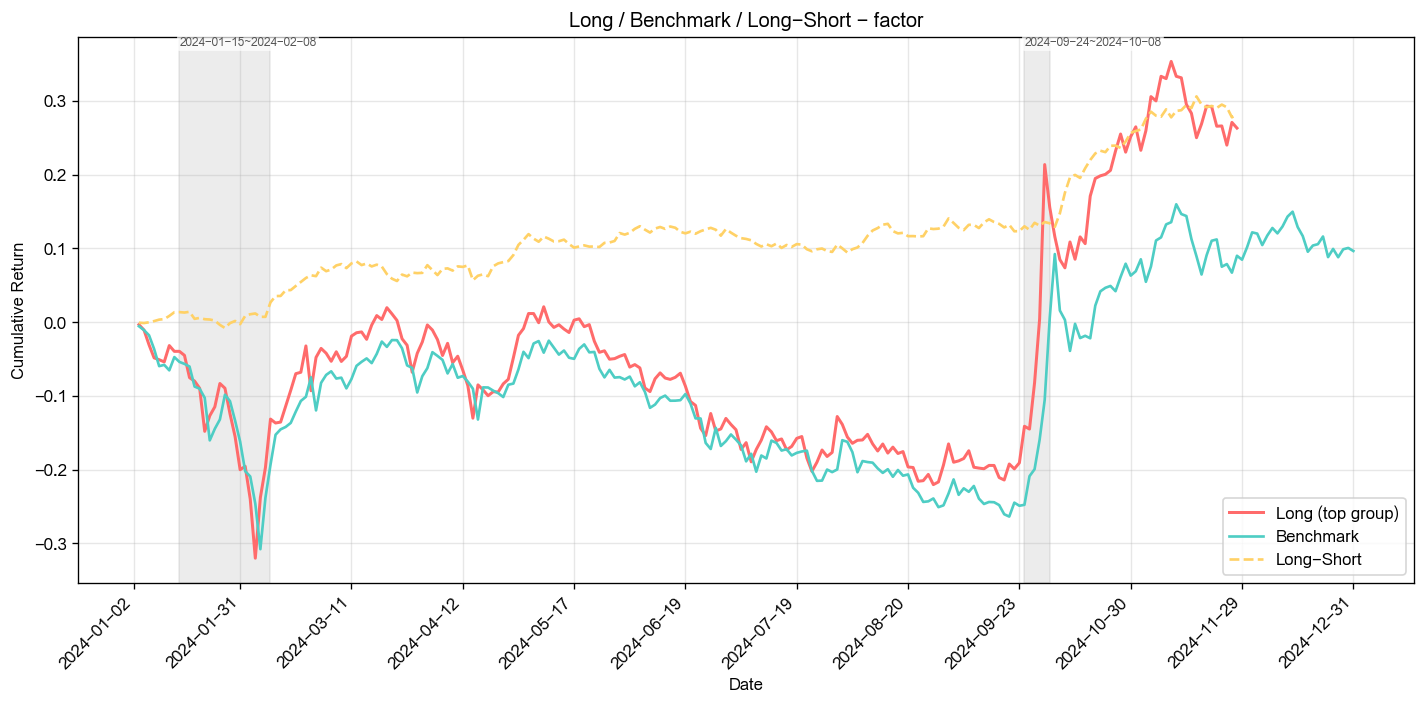
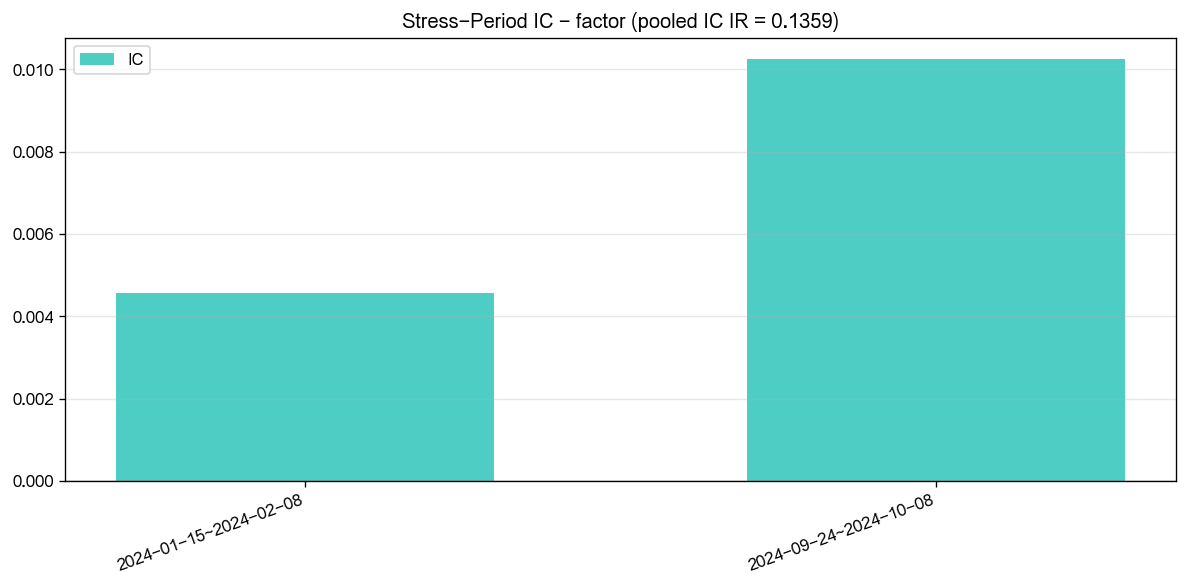
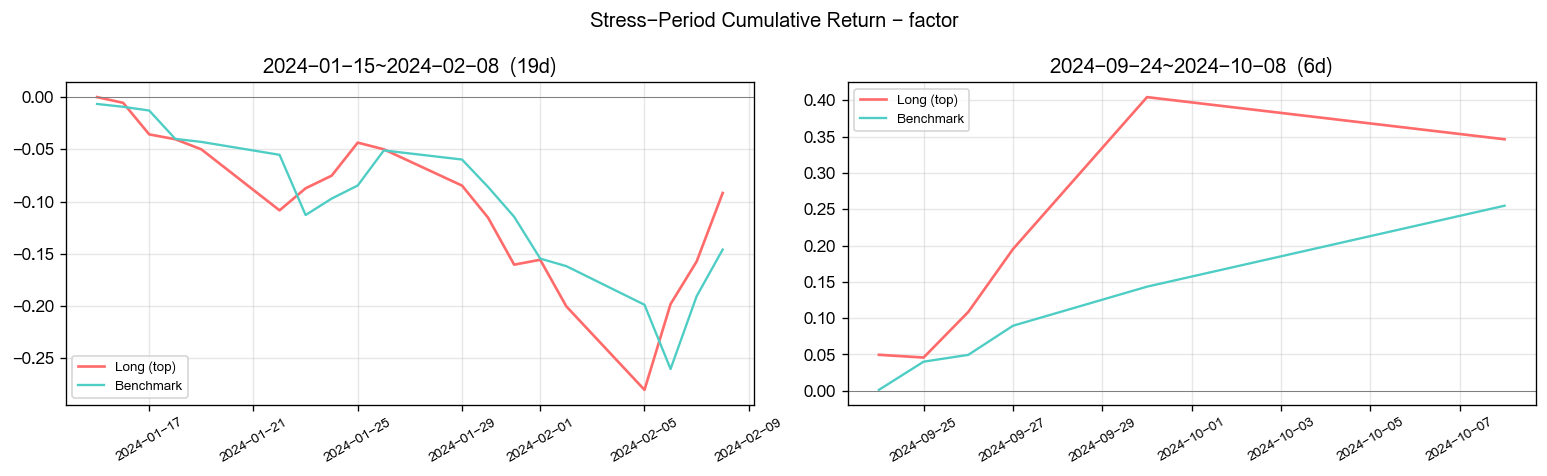

[2026-07-11 14:26:44] [info     ] ========== 因子池回归 ==========
[2026-07-11 14:26:45] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-11 14:26:45] [info     ] 获取收益率数据, 耗时: 0.6787 秒
[2026-07-11 14:26:45] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.2926 秒
[2026-07-11 14:26:45] [info     ] 统计 回归结果, 耗时: 0.085 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9482,0.0440,0.0226,1.0000
2,factor,1.8154,0.0138,0.0076,1.0000
3,amount,1.7504,0.0188,0.0107,1.0000
4,netflow_amount_main,1.5145,0.0250,0.0165,1.0000
5,gross_profit_rate_ttm,1.4957,0.0069,0.0046,1.0000
6,net_profit_rate_ttm,1.4747,0.0039,0.0026,0.8000
7,pb,1.4267,0.0096,0.0067,0.9000
8,netflow_amount_rate_main,1.4252,0.0103,0.0072,1.0000
9,bias_20,1.3848,0.0288,0.0208,0.9000
10,net_active_buy_amount_main,1.3439,0.0161,0.0120,1.0000

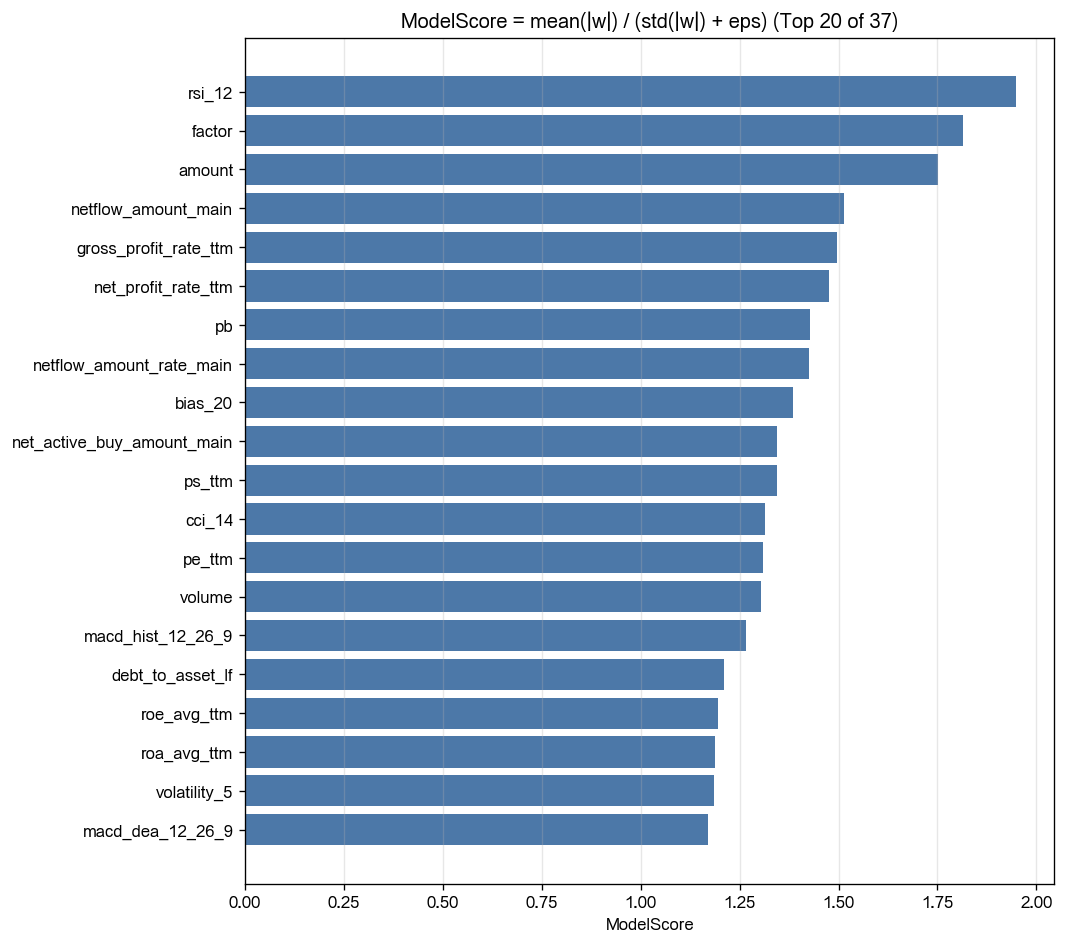
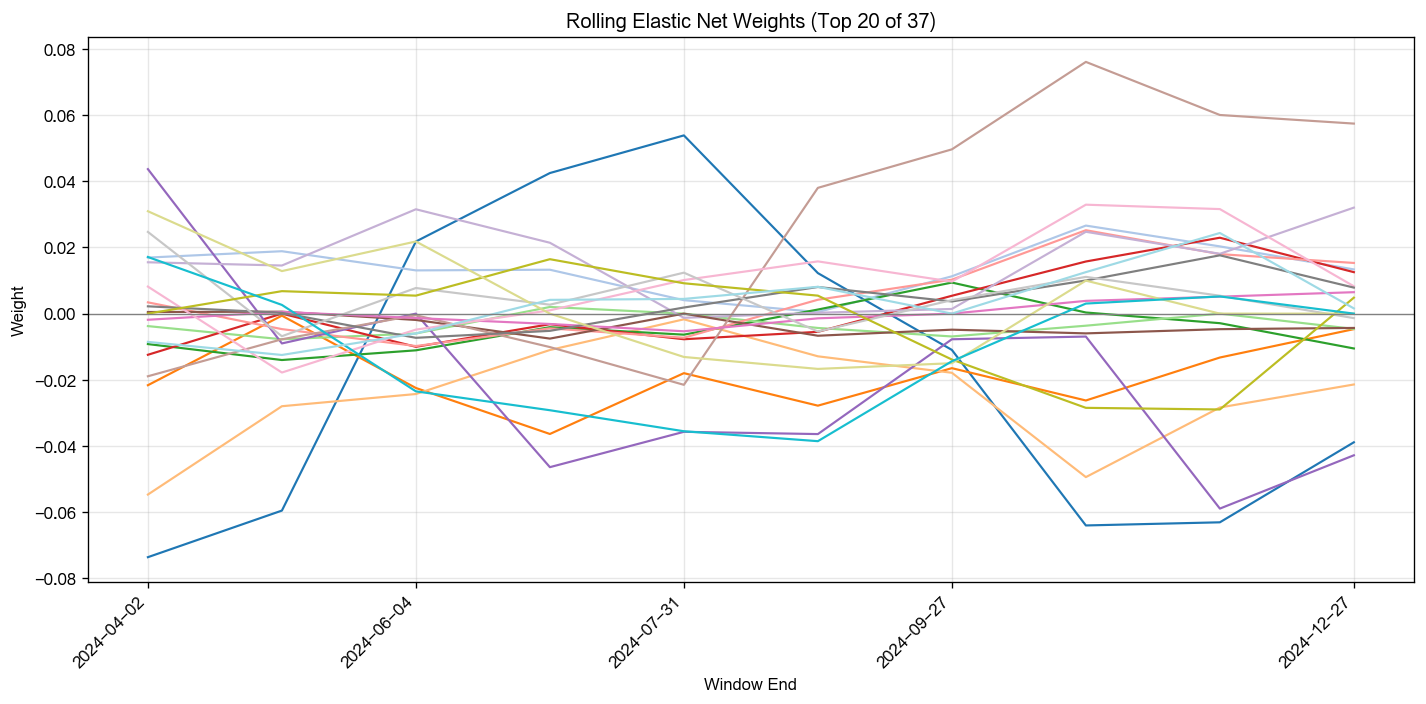
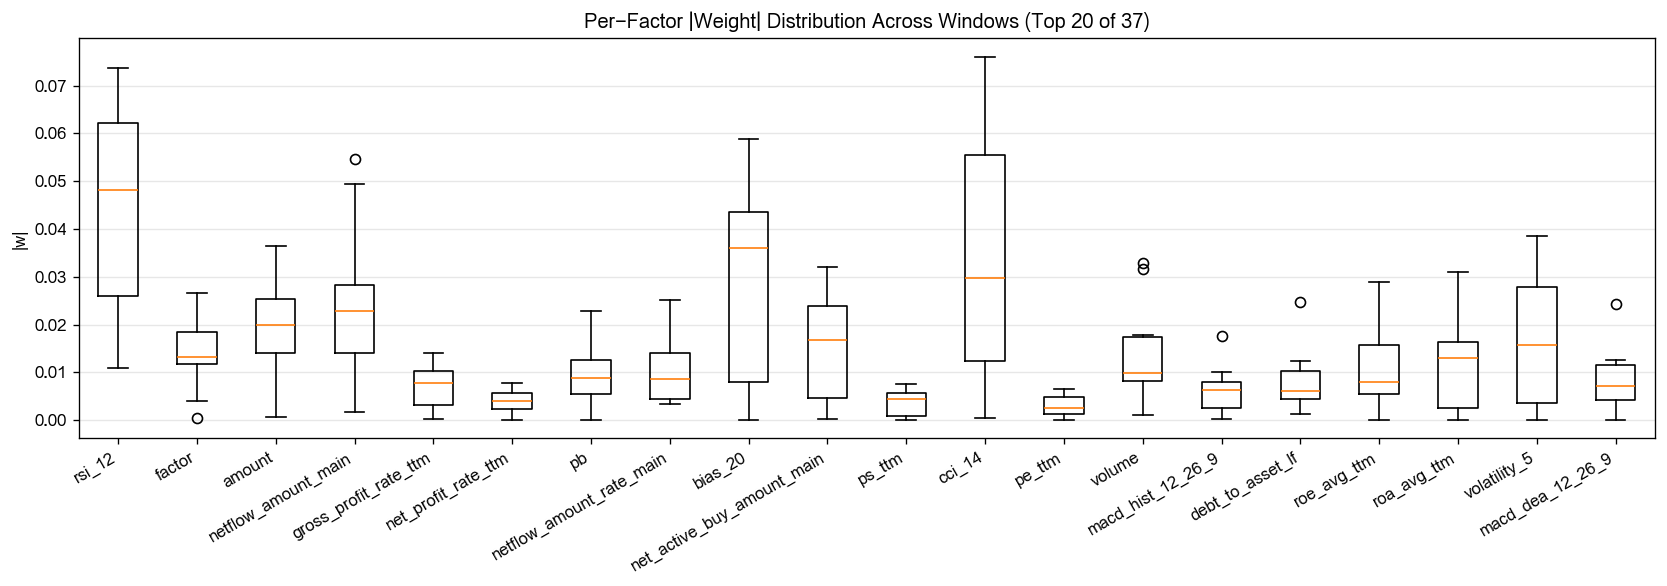
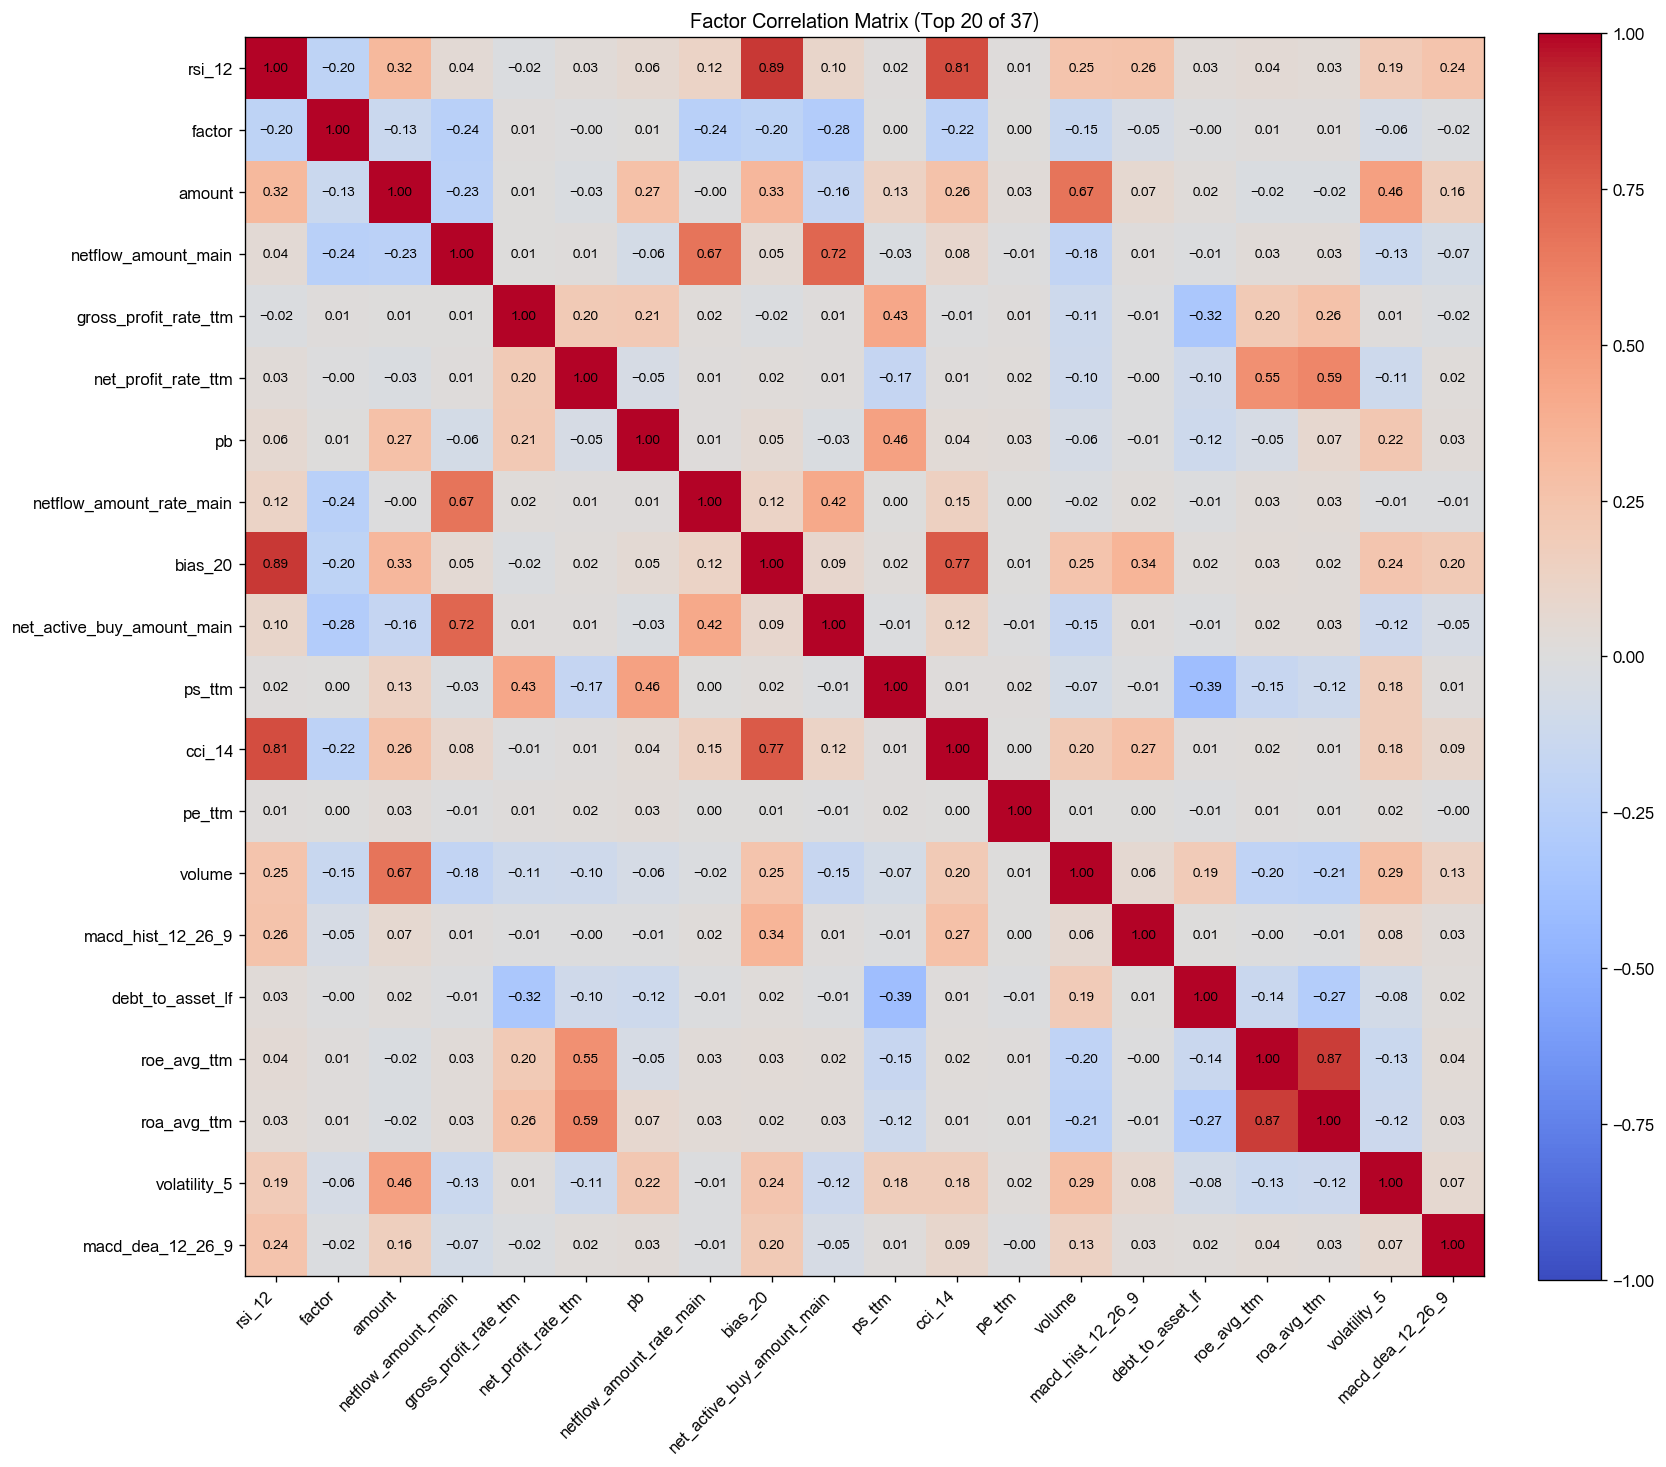

[2026-07-11 14:26:48] [warning  ] 返回的Outputs实例(size=35372023) 大于 64K, 将不会被缓存
[2026-07-11 14:26:48] [info     ] bigalpha_eval.v4 运行完成 [17.672s].


In [1]:
# 因子类别：量价 / 高频分钟 / 成交结构反转
# 因子逻辑：上涨若依赖大量成交推动，可能拥挤；下跌若伴随大量成交释放，可能有修复。
# 公式：factor = down_abs_ret_amount_intensity - up_ret_amount_intensity

def main(datasources, start_date, end_date):
    import pandas as pd
    import numpy as np
    import dai

    bar1m = datasources["bar1m"]

    sql = f"""
    WITH base AS (
        SELECT
            date, instrument, strftime(date, '%Y-%m-%d') AS trading_day,
            close, COALESCE(amount, 0)::DOUBLE AS amount,
            LAG(close, 1) OVER (PARTITION BY instrument, strftime(date, '%Y-%m-%d') ORDER BY date) AS prev_close
        FROM {bar1m}
        WHERE close > 0 AND COALESCE(amount, 0) > 0
    ),
    minute_data AS (
        SELECT *, close / NULLIF(prev_close, 0) - 1 AS ret_1m
        FROM base
        WHERE prev_close > 0
    ),
    daily_structure AS (
        SELECT
            trading_day,
            instrument,

            SUM(CASE WHEN ret_1m > 0 THEN amount ELSE 0 END) AS up_amount,
            SUM(CASE WHEN ret_1m < 0 THEN amount ELSE 0 END) AS down_amount,

            SUM(CASE WHEN ret_1m > 0 THEN ret_1m * amount ELSE 0 END) AS up_ret_amount,
            SUM(CASE WHEN ret_1m < 0 THEN abs(ret_1m) * amount ELSE 0 END) AS down_abs_ret_amount
        FROM minute_data
        WHERE ret_1m IS NOT NULL
        GROUP BY trading_day, instrument
    )
    SELECT
        CAST(trading_day AS DATETIME) AS date,
        instrument,
        down_abs_ret_amount / NULLIF(down_amount, 0)
        - up_ret_amount / NULLIF(up_amount, 0) AS factor
    FROM daily_structure
    WHERE CAST(trading_day AS DATETIME) >= CAST('{start_date}' AS DATETIME)
      AND CAST(trading_day AS DATETIME) <= CAST('{end_date}' AS DATETIME)
    """

    factor_df = dai.query(sql, filters={"date": [start_date, end_date]}, compression=True).df()
    stk_pool = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                         filters={"date": [start_date, end_date]}, compression=True).df()
    df = pd.merge(stk_pool, factor_df, how="left", on=["date", "instrument"])
    df["factor"] = df["factor"].replace([np.inf, -np.inf], np.nan)
    df["factor"] = df.groupby("date")["factor"].transform(lambda x: x.fillna(x.median()))
    df["factor"] = df["factor"].fillna(0.0)
    return df[["date", "instrument", "factor"]]

if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )